In [75]:
import geopandas as gpd
import osmnx as ox
import matplotlib.pyplot as plt
import pandas as pd

## Import roads

In [76]:
osm_roads = gpd.read_file("data/bcn_osmnx_edges.gpkg")
print(osm_roads.crs)  #CRS = Coordinate Reference System
print(osm_roads.shape)
print(osm_roads.columns.tolist())
print("Number of street segments:", len(osm_roads))

EPSG:25831
(16541, 21)
['u', 'v', 'key', 'osmid', 'highway', 'lanes', 'maxspeed', 'name', 'oneway', 'reversed', 'length', 'access', 'junction', 'ref', 'width', 'est_width', 'tunnel', 'bridge', 'service', 'segment_id', 'geometry']
Number of street segments: 16541


## Traffic Signals - OSM

In [77]:
signals = ox.features_from_place("Barcelona, Spain", tags={"highway": "traffic_signals"}) #connects to OSM and downloads all features within Barcelona that match the tags you specify
signals = signals[signals.geometry.type == 'Point'].to_crs(osm_roads.crs) #keeps only point geometries and reprojects to match the CRS of noise_streets (otherwise they come in EPSG:4326)
print(signals.crs)
print(signals.columns.tolist())
#signals.plot(figsize=(10, 10),  column='traffic_signals', legend=True, markersize=2)

#https://osmnx.readthedocs.io/en/stable/user-reference.html#osmnx.features.features_from_place

EPSG:25831
['geometry', 'highway', 'traffic_signals', 'traffic_signals:direction', 'crossing', 'button_operated', 'tactile_paving', 'traffic_signals:sound', 'traffic_signals:vibration', 'crossing:markings', 'bicycle', 'source', 'kerb', 'wheelchair', 'colour', 'mapillary', 'segregated', 'check_date:traffic_signals:vibration', 'description', 'check_date:traffic_signals:sound', 'crossing:signals', 'direction', 'supervised', 'barrier', 'red_turn:bicycle', 'name', 'name:ca', 'check_date:tactile_paving', 'was:traffic_signals:direction', 'traffic_signals:sound:remote_operated', 'proposed:highway', 'camera:mount', 'camera:type', 'man_made', 'surveillance', 'surveillance:type']


In [78]:
print(f"Total signals: {len(signals)}")
print(f"Non-null traffic_signals: {signals['traffic_signals'].notna().sum()}")
print(f"Null traffic_signals: {signals['traffic_signals'].isna().sum()}")
print("\nValue counts:")
print(signals['traffic_signals'].value_counts(dropna=False))

Total signals: 6198
Non-null traffic_signals: 1688
Null traffic_signals: 4510

Value counts:
traffic_signals
NaN                    4510
signal                 1464
pedestrian_crossing     149
blinker                  42
traffic_lights           25
crossing                  8
Name: count, dtype: int64


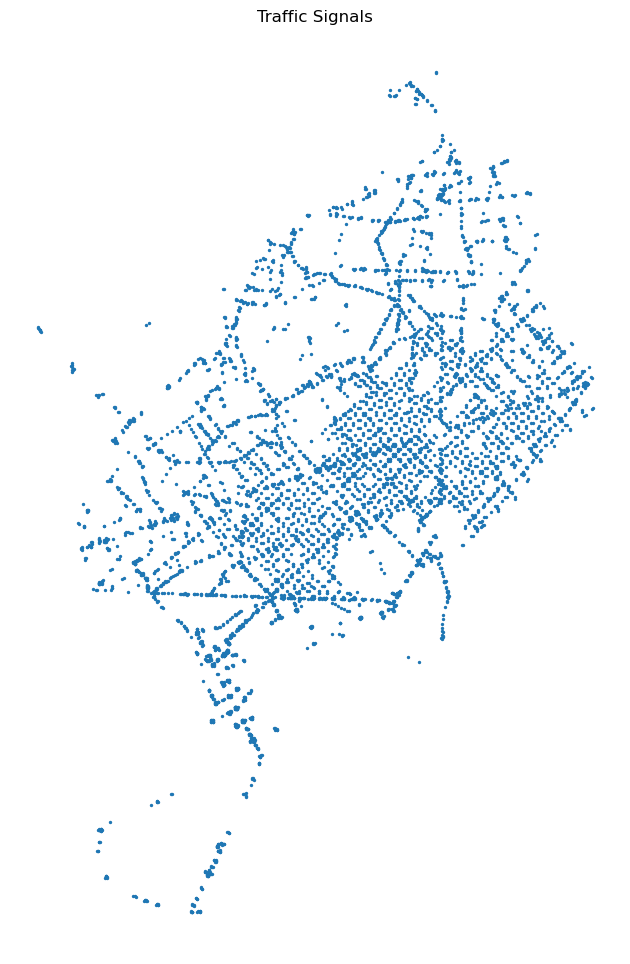

In [79]:
ax = signals.plot( markersize=2, figsize=(12, 12))
ax.set_title('Traffic Signals')
ax.set_axis_off()

## Transport - OSM

In [80]:
transport = ox.features_from_place(
    "Barcelona, Spain",
    tags={"railway": ["station", "tram_stop", "subway_entrance"],
          "highway": "bus_stop"})  # all transport — adjust tags as needed
transport = transport[transport.geometry.type == "Point"].to_crs(osm_roads.crs)
transport['transport_type'] = transport['railway'].fillna(transport['highway'])
print(transport.crs)
print(transport.columns.tolist())

EPSG:25831
['geometry', 'name', 'name:ca', 'railway', 'wheelchair', 'bench', 'bus', 'highway', 'network', 'operator', 'passenger_information_display', 'public_transport', 'ref', 'route_ref', 'shelter', 'bin', 'lit', 'tactile_paving', 'alt_name', 'alt_name:ca', 'url', 'wheelchair:description', 'bicycle', 'covered', 'level', 'check_date:shelter', 'network:wikidata', 'website', 'operator:wikidata', 'owner', 'owner:wikidata', 'ref:EU:PLC', 'train', 'uic_ref', 'kerb', 'kerb:approach_aid', 'passenger_information_display:speech_output', 'network:bus', 'network:guid', 'network:short', 'network:wikipedia', 'tram', 'departures_board', 'defibrillator:access', 'defibrillator:indoor', 'defibrillator:location', 'defibrillator:location:en', 'defibrillator:wheelchair:access', 'emergency', 'panoramax', 'platforms', 'station', 'subway', 'survey:date', 'wikidata', 'wikimedia_commons', 'wikipedia', 'emergency:fire_extinguisher', 'operator:short', 'panoramax:0', 'addr:city', 'addr:housenumber', 'addr:postc

In [81]:
print(f"Total transport points: {len(transport)}")
print(f"Non-null transport points: {transport['transport_type'].notna().sum()}")
print(f"Null transport points: {transport['transport_type'].isna().sum()}")
print("\nValue counts:")
print(transport['transport_type'].value_counts(dropna=False))

Total transport points: 3114
Non-null transport points: 3114
Null transport points: 0

Value counts:
transport_type
bus_stop           2531
subway_entrance     369
station             147
tram_stop            67
Name: count, dtype: int64


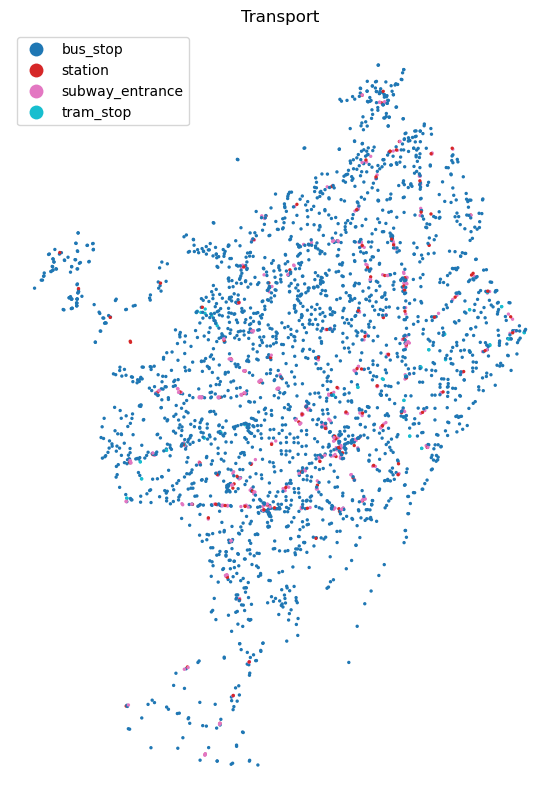

In [82]:
ax = transport.plot(column='transport_type', legend=True, markersize=2, figsize=(10, 10))
ax.set_title('Transport')
ax.set_axis_off()

## Points Of Interest (POIs) - OSM

In [83]:
pois = ox.features_from_place(
    "Barcelona, Spain",
    tags={"amenity": True}   # all amenities — adjust tags as needed
)
pois = pois[pois.geometry.type == "Point"].to_crs(osm_roads.crs)
print(pois.crs)
print(pois.columns.tolist())


EPSG:25831
['geometry', 'access', 'amenity', 'fee', 'maxheight', 'parking', 'addr:city', 'addr:full', 'addr:housenumber', 'addr:postcode', 'addr:street', 'check_date', 'contact:phone', 'dispensing', 'healthcare', 'name', 'name:ca', 'ref', 'source', 'source:date', 'opening_hours', 'phone', 'website', 'wheelchair', 'alt_name', 'contact:instagram', 'opening_hours:signed', 'location', 'recycling:cans', 'recycling:food_waste', 'recycling:glass_bottles', 'recycling:green_waste', 'recycling:paper', 'recycling:plastic', 'recycling_type', 'lit', 'man_made', 'operator', 'operator:wikidata', 'capacity', 'recycling:waste', 'short_name', 'brand', 'brand:wikidata', 'brand:wikipedia', 'cuisine', 'diet:gluten_free', 'internet_access', 'takeaway', 'toilets', 'toilets:wheelchair', 'indoor_seating', 'outdoor_seating', 'layer', 'designation', 'recycling:batteries', 'recycling:books', 'recycling:cardboard', 'recycling:cartons', 'recycling:clothes', 'recycling:electrical_appliances', 'recycling:magazines', 

### Filter and classify POIs 

In [84]:
filtered_categories = ['restaurant', 'cafe', 'bar', 'pub', 'nightclub', 'fast_food', 'food_court','music_venue', 'cinema', 'theatre','shopping_mall', 'shop', 'supermarket', 'marketplace']
pois_filtered = pois[pois['amenity'].isin(filtered_categories)]

#sensitive_categories = ['hospital', 'clinic','school', 'kindergarten', 'university', 'research_institute', 'library','social_facility', 'social_centre', 'community_centre']
#pois_sensitive = pois[pois['amenity'].isin(sensitive_categories)]

traffic_categories = ['parking', 'parking_lot','taxi']
pois_traffic = pois[pois['amenity'].isin(traffic_categories)]   

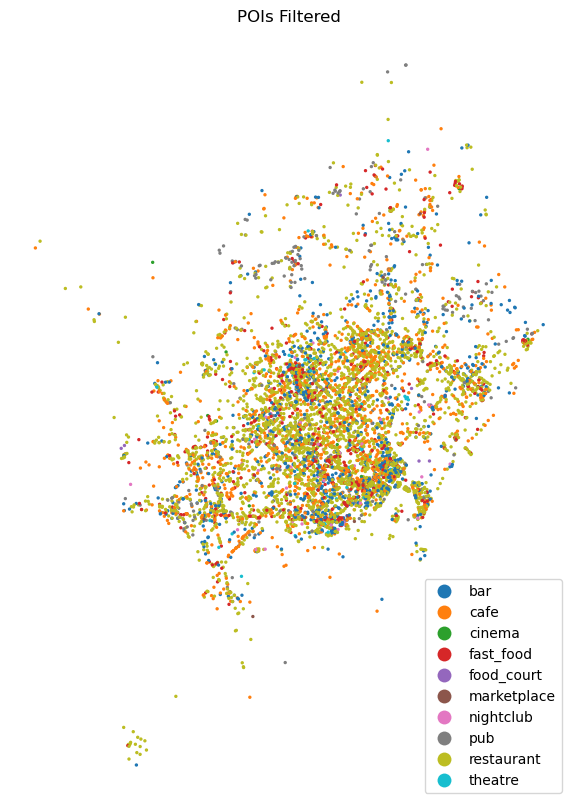

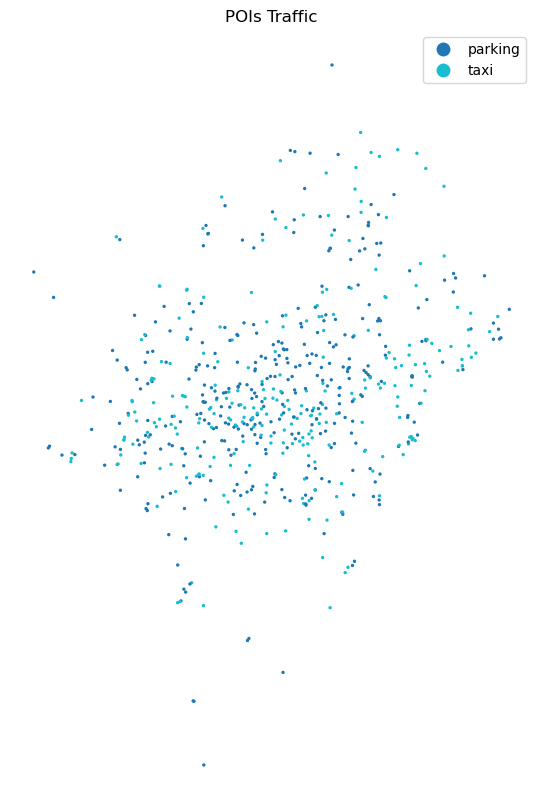

In [85]:
ax = pois_filtered.plot(figsize=(10, 10), column='amenity', legend=True, markersize=2)
ax.set_title('POIs Filtered')
ax.set_axis_off()

# ax = pois_sensitive.plot(figsize=(10, 10), column='amenity', legend=True, markersize=2)
# ax.set_title('POIs Sensitive')
# ax.set_axis_off()

ax = pois_traffic.plot(figsize=(10, 10), column='amenity', legend=True, markersize=2)
ax.set_title('POIs Traffic')
ax.set_axis_off()


## Signals in 50 m buffer

In [86]:
# Create 50 m buffer around each street segment
buffered_50 = osm_roads.copy()
buffered_50['geometry'] = buffered_50.geometry.buffer(50)

### Count signals per buffer

In [87]:
signals_join = gpd.sjoin(signals, buffered_50, how="right", predicate="within") #spatial join to combine GeoDataFrames (signals and buffered streets), how="right" to keep all buffered street segments, predicate="within" to match signals that fall within the buffered street segments
signals_count = signals_join.groupby(signals_join.index).size().rename("signal_count") #groupby() to group by the index of the buffered street segments, size() to count the number of signals in each segment, rename() to rename the resulting Series to "signal_count"


In [88]:
# Join the counts back to GeoDataFrame
osm_roads = osm_roads.join(signals_count)

# Normalise every 100 m and cap at 15 to avoid outliers dominating the map
osm_roads['signal_count_per_100m'] = osm_roads['signal_count'] / osm_roads['length'] *100
osm_roads['signal_count_per_100m'] = osm_roads['signal_count_per_100m'].clip(upper=50)


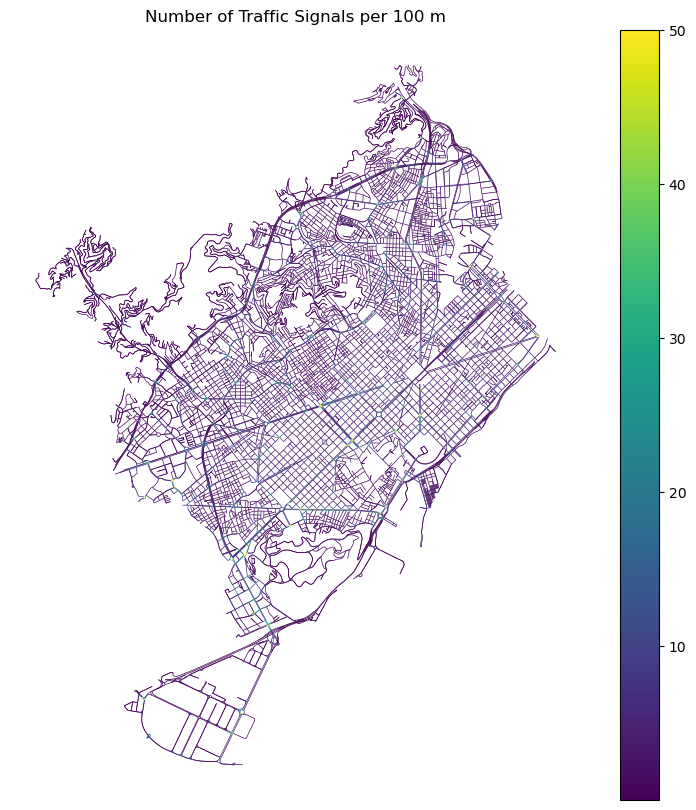

In [89]:
ax = osm_roads.plot(column='signal_count_per_100m', cmap='viridis', linewidth=0.5, legend=True, figsize=(10, 10))
ax.set_title('Number of Traffic Signals per 100 m')
ax.set_axis_off()

In [90]:
# Create 100 m buffer around each street segment
buffered_100 = osm_roads.copy()
buffered_100['geometry'] = buffered_100.geometry.buffer(100)

## Transport in 100 m buffer

In [91]:
transport_join = gpd.sjoin(transport, buffered_100, how="right", predicate="within") 
transport_count = transport_join.groupby(transport_join.index).size().rename("transport_count")
transport_count

traffic_join = gpd.sjoin(pois_traffic, buffered_100, how="right", predicate="within") 
traffic_count = traffic_join.groupby(traffic_join.index).size().rename("traffic_count")
traffic_count

transport_count + traffic_count

0        4
1        8
2        2
3        5
4        5
        ..
16536    2
16537    2
16538    2
16539    2
16540    2
Length: 16541, dtype: int64

In [92]:
# Join the counts back to GeoDataFrame
osm_roads = osm_roads.join(transport_count)
osm_roads = osm_roads.join(traffic_count)

# Normalise every 100 m and cap at 15 to avoid outliers dominating the map
osm_roads['transport_count_per_100m'] = (osm_roads['transport_count'] + osm_roads['traffic_count']) / osm_roads['length'] *100
osm_roads['transport_count_per_100m'] = osm_roads['transport_count_per_100m'].clip(upper=50)

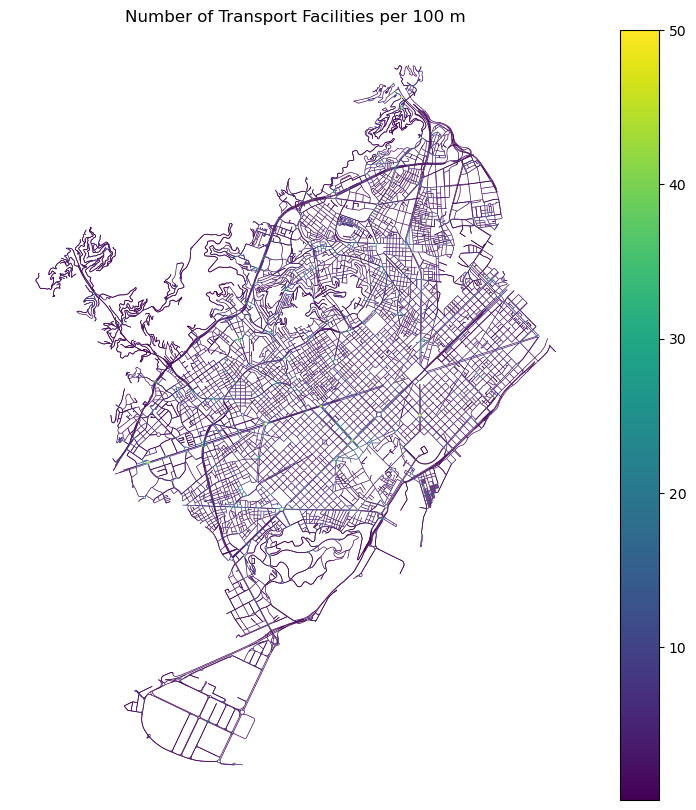

In [93]:
ax = osm_roads.plot(column='transport_count_per_100m', cmap='viridis', linewidth=0.5, legend=True, figsize=(10, 10))
ax.set_title('Number of Transport Facilities per 100 m')
ax.set_axis_off()

## POIs noisy in 100 m buffer

In [94]:
## POI Filtered in 100 m buffer
pois_join = gpd.sjoin(pois_filtered, buffered_100, how="right", predicate="within") 
pois_count = pois_join.groupby(pois_join.index).size().rename("pois_count")
pois_count

0         2
1        18
2        20
3        10
4        11
         ..
16536     2
16537     2
16538     2
16539     2
16540     2
Name: pois_count, Length: 16541, dtype: int64

In [95]:
# Join the counts back to GeoDataFrame
osm_roads = osm_roads.join(pois_count)

# Normalise every 100 m and cap at 50 signals per 100 m to avoid outliers dominating the map
osm_roads['pois_count_per_100m'] = osm_roads['pois_count'] / osm_roads['length'] *100
osm_roads['pois_count_per_100m'] = osm_roads['pois_count_per_100m'].clip(upper=100)

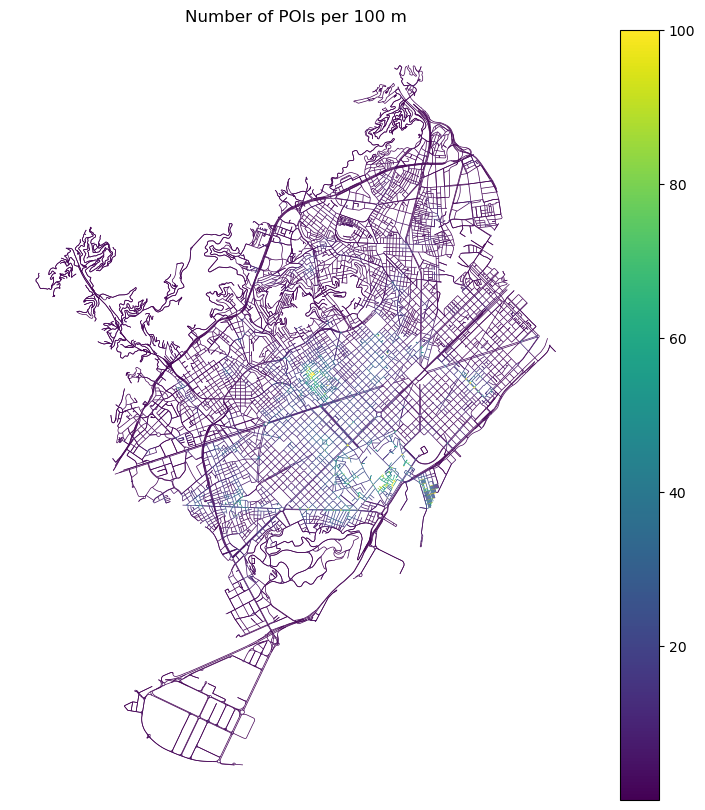

In [96]:
ax = osm_roads.plot(column='pois_count_per_100m', cmap='viridis', linewidth=0.5, legend=True, figsize=(10, 10))
ax.set_title('Number of POIs per 100 m')
ax.set_axis_off()

## Create Dataset

In [97]:
dataset = pd.DataFrame({
    "road_id": osm_roads['segment_id'],
    "signals": osm_roads['signal_count_per_100m'],
    "transport": osm_roads['transport_count_per_100m'],
    "pois": osm_roads['pois_count_per_100m'],
}).fillna(0) #fillna(0) to replace any NaN values (which indicate no signals or POIs in that segment) with 0
dataset.head()

,road_id,signals,transport,pois
0,21638845_885308258_0,10.587702,14.116936,7.058468
1,21638845_13175411896_0,2.270953,1.297688,2.919797
2,21638865_30343650_0,6.465793,12.931587,100.000000
3,21638867_1636238503_0,6.355789,31.778944,63.557887
4,21638867_1403082237_0,6.486238,32.431189,71.348616


## Export CSV

In [98]:
import os
output_dir = "data"
os.makedirs(output_dir, exist_ok=True)

path = os.path.join(output_dir, "osm_points_features.csv")

dataset.to_csv(path, index=False)

print(f"Exported: {path}")

Exported: data\osm_points_features.csv
